In [ ]:
# ============================================================
# ESN Hyperparameter Grid Search
# Train once on first part, then test any chosen window
# with local test warmup + closed-loop prediction
# ============================================================

import numpy as np
import itertools
import time
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.mat_gen import uniform
import reservoirpy

reservoirpy.set_seed(42)

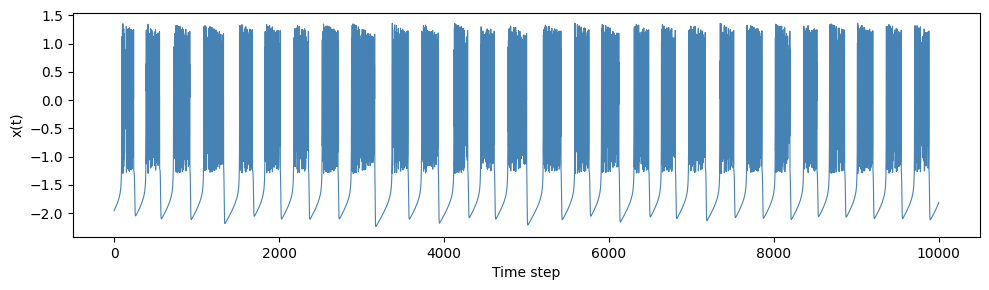

In [9]:
# LOAD DATA
# data should be a 1D numpy array
dataset = np.loadtxt('../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[: ,0]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Time step')
ax.set_ylabel('x(t)')
plt.tight_layout()
plt.show()

In [ ]:
# PREPARE DATA
data = dataset.reshape(-1, 1)
# X[t] = data[t], Y[t] = data[t+1]
X = data[:-1]
Y = data[1:]

# ----------------------------------------------------------
# 2. GLOBAL DATA SPLIT SETTINGS
# ----------------------------------------------------------
train_len = 2000          # train on [0 : train_len]
train_warmup = 100        # discard first transient states during fit

# Test window can be right after training or far away
test_start = 2000
test_len = 500

warmup_len = 200          # synchronization using true data inside chosen test window

# Training data
X_train = X[:train_len]
Y_train = Y[:train_len]

# Chosen test window
X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]

# Prediction portion is after local test warmup
pred_len = test_len - warmup_len
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

# ----------------------------------------------------------
# 3. DEFINE PARAMETER GRID
# ----------------------------------------------------------
param_grid = {
    'units':         [500, 800, 1000, 2000],
    'sr':            [0.95, 0.99, 1.2, 1.3, 1.5],
    'lr':            [0.1, 0.3, 0.5, 1.0],
    'input_scaling': [0.05, 0.1, 0.5, 1.0],
    'ridge':         [1e-8, 1e-6, 1e-4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Total combinations to evaluate: {len(combos)}")

# ----------------------------------------------------------
# 4. EVALUATION FUNCTION
# ----------------------------------------------------------
def evaluate_esn(units, sr, lr, input_scaling, ridge, seed=42):
    """
    Build, train, reset, synchronize on chosen test window,
    then run closed-loop prediction and return NRMSE.
    """
    try:
        # Recurrent matrix: dense uniform in [-0.5, 0.5], then scaled to sr
        # Input matrix: dense uniform with scaled range
        # Bias: kept at the baseline range used before
        reservoir = Reservoir(
            units=int(units),
            lr=lr,
            W=uniform(low=-0.5, high=0.5, connectivity=1.0, sr=sr),
            Win=uniform(low=-0.5 * input_scaling, high=0.5 * input_scaling, connectivity=1.0),
            bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
            activation="tanh",
            seed=seed
        )

        readout = Ridge(ridge=ridge)
        esn = reservoir >> readout

        # -----------------------
        # Train on first segment
        # -----------------------
        esn.fit(X_train, Y_train, warmup=train_warmup)

        # -----------------------
        # Reset before any test window
        # -----------------------
        esn.reset()

        # -----------------------
        # Synchronize on first part of chosen test window
        # -----------------------
        if warmup_len > 0:
            esn.run(X_test[:warmup_len])

        # -----------------------
        # Closed-loop prediction on the rest
        # -----------------------
        Y_pred = []
        current_input = X_test[warmup_len:warmup_len + 1]

        for _ in range(pred_len):
            pred = esn.run(current_input)
            pred = np.asarray(pred).reshape(1, -1)
            Y_pred.append(pred[0, 0])
            current_input = pred

        Y_pred = np.array(Y_pred)

        # Divergence check
        if np.any(np.isnan(Y_pred)) or np.max(np.abs(Y_pred)) > 1e6:
            return np.inf

        rmse = np.sqrt(np.mean((Y_true - Y_pred) ** 2))
        nrmse = rmse / np.std(Y_true)
        return nrmse

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf

# ----------------------------------------------------------
# 5. RUN GRID SEARCH
# ----------------------------------------------------------
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params)
    results.append({**params, 'nrmse': nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(
            f"[{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start

# ----------------------------------------------------------
# 6. RESULTS
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("GRID SEARCH COMPLETE")
print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"Total time     : {total_time:.1f}s ({total_time/len(combos):.2f}s per trial)")
print(f"Best NRMSE     : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:20s} = {v}")
print("=" * 60)

# ----------------------------------------------------------
# 7. TOP 10 CONFIGURATIONS
# ----------------------------------------------------------
results_sorted = sorted(results, key=lambda r: r['nrmse'])

print("\nTop 10 configurations:")
print(f"{'Rank':>4}  {'units':>5}  {'sr':>5}  {'lr':>4}  {'in_sc':>6}  {'ridge':>8}  {'NRMSE':>10}")
print("-" * 62)

for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['sr']:5.2f}  "
        f"{r['lr']:4.1f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['ridge']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# VISUALIZE BEST ESN
import matplotlib.pyplot as plt
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge
import numpy as np

# REBUILD BEST ESN
best_reservoir = Reservoir(
    units=int(best_params['units']),
    lr=best_params['lr'],
    W=uniform(low=-0.5, high=0.5, connectivity=1.0, sr=best_params['sr']),
    Win=uniform(
        low=-0.5 * best_params['input_scaling'],
        high=0.5 * best_params['input_scaling'],
        connectivity=1.0
    ),
    bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
    activation="tanh",
    seed=42
)

best_readout = Ridge(ridge=best_params['ridge'])
best_esn = best_reservoir >> best_readout

# TRAIN
best_esn.fit(X_train, Y_train, warmup=100)

# TEST (RESET + LOCAL WARMUP + CLOSED LOOP)
best_esn.reset()

if warmup_len > 0:
    best_esn.run(X_test[:warmup_len])

pred_len = test_len - warmup_len

Y_pred_best = []
current_input = X_test[warmup_len:warmup_len + 1]

for _ in range(pred_len):
    pred = best_esn.run(current_input)
    pred = np.asarray(pred).reshape(1, -1)
    Y_pred_best.append(pred[0, 0])
    current_input = pred

Y_pred_best = np.array(Y_pred_best)

# Ground truth aligned
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

mse = np.mean((Y_true - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)


fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test[:, 0], c='green', label="Ground truth", linewidth=1.2)
ax.axvline(warmup_len, linestyle="--", c='k',linewidth=1.0, label="Warmup end")
ax.plot(np.arange(warmup_len, warmup_len + pred_len), Y_pred_best,
        linestyle="--", c='red', linewidth=1.2, label="ESN closed-loop prediction")

ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={int(best_params['units'])}, sr={best_params['sr']}, "
    f"lr={best_params['lr']}, in_sc={best_params['input_scaling']}, "
    f"ridge={best_params['ridge']:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()

Total combinations to evaluate: 960
[20/960]  elapsed: 4s  current best NRMSE: 1.396053
[40/960]  elapsed: 8s  current best NRMSE: 1.396053
[60/960]  elapsed: 12s  current best NRMSE: 1.396053
[80/960]  elapsed: 15s  current best NRMSE: 1.396053
[100/960]  elapsed: 19s  current best NRMSE: 1.377313
[120/960]  elapsed: 23s  current best NRMSE: 1.377313
[140/960]  elapsed: 27s  current best NRMSE: 1.377313
[160/960]  elapsed: 31s  current best NRMSE: 1.307593
[180/960]  elapsed: 34s  current best NRMSE: 1.307593
[200/960]  elapsed: 38s  current best NRMSE: 1.307593
[220/960]  elapsed: 42s  current best NRMSE: 1.307593
[240/960]  elapsed: 46s  current best NRMSE: 1.157333
[260/960]  elapsed: 56s  current best NRMSE: 1.157333
[280/960]  elapsed: 66s  current best NRMSE: 1.157333
[300/960]  elapsed: 77s  current best NRMSE: 1.157333
[320/960]  elapsed: 87s  current best NRMSE: 1.157333
[340/960]  elapsed: 99s  current best NRMSE: 1.157333
[360/960]  elapsed: 111s  current best NRMSE: 1.1573